Размер выборки: 220
Выборочное среднее: 172.05055454545456
Несмещенная оценка выборочной дисперсии: 164.39736432121214
Выборочное с.к.о: 12.821753558745861
Доверительный интервал (уровень надежности 0.95): (170.347, 173.754)
Ожидаемые частоты (до объединения крайних интервалов):
[ 5.32809228 13.81163309 27.17793786 40.60117749 46.0514488  39.65889713
 25.93096196 12.87192762  4.85021903  1.38707256]
Ожидаемые частоты:
[ 5.32809228 13.81163309 27.17793786 40.60117749 46.0514488  39.65889713
 25.93096196 12.87192762  6.23729159]
Количество интервалов: 9
Статистика хи^2: 2.7954582307585523
Степени свободы: 6
P-value: 0.8340462640629583
Гипотеза о нормальном распределении НЕ отвергается


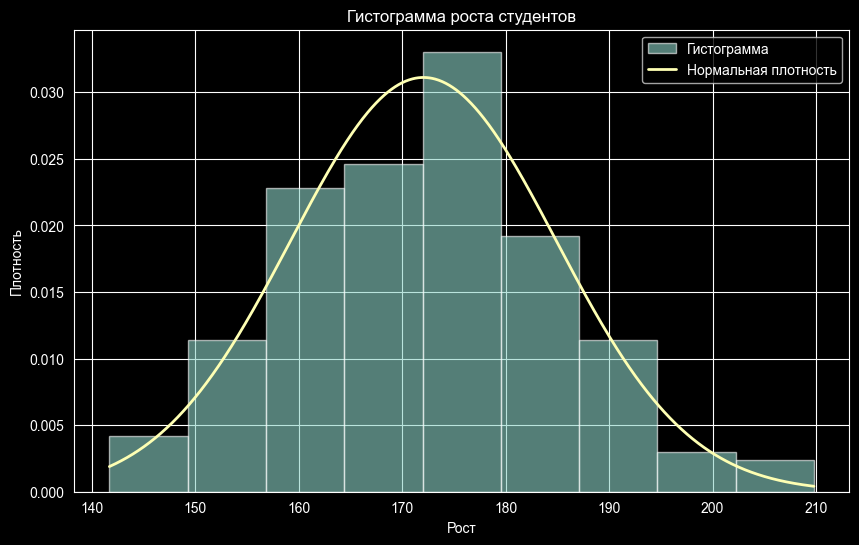

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

confidence = 0.95  # Уровень надежности
alpha = 0.05  # Уровень значимости
k = 10  # Число интервалов (потом объединим крайние интервалы, где ожидаемые частоты <5)

data = np.loadtxt('рост.dat')
n = len(data)
print(f"Размер выборки: {n}")

# Находим оценки параметров
mean = np.mean(data)  # выборочное среднее
var = np.var(data, ddof=1)  # несмещенная оценка выборочной дисперсии
std = np.sqrt(var)  # выборочное с.к.о
print("Выборочное среднее:", mean)
print("Несмещенная оценка выборочной дисперсии:", var)
print("Выборочное с.к.о:", std)

# Интервальная оценка через распределение Стьюдента
t_crit = stats.t.ppf((1 + confidence) / 2, df=n - 1)
margin = t_crit * std / np.sqrt(n)

left = mean - margin
right = mean + margin

print(f"Доверительный интервал (уровень надежности {confidence}): ({left:.3f}, {right:.3f})")

# Интервалы для хи^2
counts, bins = np.histogram(data, bins=k)

# Считаем ожидаемые частоты
expected = []

for i in range(k):
    p = stats.norm.cdf(bins[i + 1], mean, std) - stats.norm.cdf(bins[i], mean, std)
    expected.append(n * p)

expected = np.array(expected)
print(f"Ожидаемые частоты (до объединения крайних интервалов):\n{expected}")

# Объединение интервалов, где ожидаемые частоты <5
while np.any(expected < 5) and len(expected) > 2:
    i = np.argmin(expected)
    if i == len(expected) - 1:
        i -= 1
    counts[i] += counts[i + 1]
    expected[i] += expected[i + 1]
    counts = np.delete(counts, i + 1)
    expected = np.delete(expected, i + 1)
    bins = np.delete(bins, i + 1)

k = len(expected)
print(f"Ожидаемые частоты:\n{expected}")
print(f"Количество интервалов: {k}")

# Вычисляем статистику хи^2
hi2_stat = np.sum((counts - expected) ** 2 / expected)
print(f"Статистика хи^2: {hi2_stat}")

# p-value
df = k - 2 - 1  # степени свободи: k - количество интервалов, 1 - ограничение на сумму вероятностей, 2 - потому что оценены среднее и с.к.о
p_value = 1 - stats.chi2.cdf(hi2_stat, df)
print(f"Степени свободы: {df}")
print(f"P-value: {p_value}")

if p_value > alpha:
    print("Гипотеза о нормальном распределении НЕ отвергается")
else:
    print("Гипотеза о нормальном распределении отвергается")

# Отображаем нашу гистограмму
x = np.linspace(min(data), max(data), 1000)
pdf = stats.norm.pdf(x, loc=mean, scale=std)
plt.figure(figsize=(10, 6))
plt.hist(data, bins=k, density=True, alpha=0.6, label='Гистограмма')
plt.plot(x, pdf, linewidth=2, label='Нормальная плотность')
plt.xlabel('Рост')
plt.ylabel('Плотность')
plt.title('Гистограмма роста студентов')
plt.legend()
plt.grid(True)
plt.show()

#### Выборочная дисперсия

$S^2=\frac{1}{n-1}\sum_{i=1}^{n}(X_i-\bar X)^2$

#### Интервальная оценка через распределение Стьюдента

$\bar X \pm t_{0.975,n-1}\frac{S}{\sqrt n}$

#### Гипотезы

$H_0: X \sim N(\mu,\sigma^2)$

$H_1: \text{распределение не является нормальным}$

#### Вероятность попадания в интервал

$p_i = F(b_i)-F(a_i)$

#### Ожидаемое число наблюдений

$E_i = np_i$

#### Статистика хи^2

$\chi^2=\sum_{i=1}^{k}\frac{(O_i-E_i)^2}{E_i}$

#### Нормальноя распределение

$N(\bar X,S^2)$
